In [1]:
import numpy as np
import pandas as pd

print("🔍 CHECKING DATA INTEGRITY")
print("="*70)

X_fusion = np.load('../../data/processed/X_fusion_val.npy')
print(f"\n✅ X_fusion_val.npy exists")
print(f"   Shape: {X_fusion.shape}")
print(f"   Expected: (4643, 33)")
print(f"   Match: {'✅ YES' if X_fusion.shape == (4643, 33) else '❌ NO - DATA CORRUPTED!'}")

import os
if os.path.exists('../../data/processed/X_fusion_val_corrected.npy'):
    X_corrected = np.load('../../data/processed/X_fusion_val_corrected.npy')
    print(f"\n⚠️ X_fusion_val_corrected.npy also exists: {X_corrected.shape}")
    print(f"   These are DIFFERENT files, original should be safe")
else:
    print(f"\n✅ X_fusion_val_corrected.npy does NOT exist")
    print(f"   Original file was never overwritten")

agent3_preds = X_fusion[:, 18:27]
print(f"\n📊 Agent 3 predictions in original fusion:")
print(f"   Mean prediction: {agent3_preds.mean():.3f}")
print(f"   Range: [{agent3_preds.min():.3f}, {agent3_preds.max():.3f}]")
print(f"   Expected mean: ~0.30-0.40 (if original)")
print(f"   This looks: {'✅ ORIGINAL' if 0.25 < agent3_preds.mean() < 0.45 else '⚠️ POSSIBLY MODIFIED'}")

y_sepsis = np.load('../../data/processed/y_fusion_val_sepsis.npy')
print(f"\n✅ Disease labels exist")
print(f"   Sepsis: {len(y_sepsis)} samples, {y_sepsis.sum()} positive ({y_sepsis.sum()/len(y_sepsis)*100:.1f}%)")
print(f"   Expected: ~18-19% positive")
print(f"   Match: {'✅ YES' if 17 < (y_sepsis.sum()/len(y_sepsis)*100) < 20 else '⚠️ DIFFERENT'}")

print("\n" + "="*70)
print("VERDICT:")
if X_fusion.shape == (4643, 33) and 0.25 < agent3_preds.mean() < 0.45:
    print("✅ ORIGINAL DATA IS INTACT!")
    print("✅ Safe to rerun notebook 11 - should reproduce 0.892 AUC")
else:
    print("⚠️ DATA MAY HAVE BEEN MODIFIED!")

🔍 CHECKING DATA INTEGRITY

✅ X_fusion_val.npy exists
   Shape: (4643, 33)
   Expected: (4643, 33)
   Match: ✅ YES

✅ X_fusion_val_corrected.npy does NOT exist
   Original file was never overwritten

📊 Agent 3 predictions in original fusion:
   Mean prediction: 0.295
   Range: [0.001, 0.997]
   Expected mean: ~0.30-0.40 (if original)
   This looks: ✅ ORIGINAL

✅ Disease labels exist
   Sepsis: 4643 samples, 867 positive (18.7%)
   Expected: ~18-19% positive
   Match: ✅ YES

VERDICT:
✅ ORIGINAL DATA IS INTACT!
✅ Safe to rerun notebook 11 - should reproduce 0.892 AUC


In [2]:
"""
Train Fusion Coordinator

Goals:
1. Load fusion features from Day 10
2. Split into train/test
3. Train fusion coordinator models
4. Create baseline (simple averaging)
5. Compare fusion vs baseline
6. Statistical analysis
7. Save results
"""

import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    f1_score, 
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from scipy import stats

# Communication protocol
from src.communication.protocol import DISEASE_LIST

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports complete")
print(f"\nDisease list: {DISEASE_LIST}")

✅ Imports complete

Disease list: ['SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 'ANEMIA', 'PANCREATITIS']


In [3]:
print("📂 Loading fusion data\n")

# Load fusion features
X_fusion = np.load('../../data/processed/X_fusion_val.npy')
print(f"✅ Loaded fusion features: {X_fusion.shape}")

# Load labels for each disease
y_fusion = {}
for disease in DISEASE_LIST:
    disease_filename = disease.lower()
    y_fusion[disease] = np.load(f'../../data/processed/y_fusion_val_{disease_filename}.npy')

print(f"✅ Loaded labels for {len(DISEASE_LIST)} diseases")

# Display feature structure
print(f"\n📊 Feature Structure (33 features):")
print(f"   Indices 0-8:   Agent 1 probabilities (9 diseases)")
print(f"   Indices 9-17:  Agent 2 probabilities (9 diseases)")
print(f"   Indices 18-26: Agent 3 probabilities (9 diseases)")
print(f"   Indices 27-29: Agent confidences (3 values)")
print(f"   Indices 30-32: Data availability flags (3 values)")

# Display disease distribution
print(f"\n📊 Disease Distribution:")
for disease in DISEASE_LIST:
    n_positive = sum(y_fusion[disease])
    prevalence = n_positive / len(y_fusion[disease]) * 100
    print(f"   {disease:30s} {n_positive:4d} / {len(y_fusion[disease])} ({prevalence:5.1f}%)")

print(f"\n✅ Data loaded successfully!")

📂 Loading fusion data from Day 10...

✅ Loaded fusion features: (4643, 33)
✅ Loaded labels for 9 diseases

📊 Feature Structure (33 features):
   Indices 0-8:   Agent 1 probabilities (9 diseases)
   Indices 9-17:  Agent 2 probabilities (9 diseases)
   Indices 18-26: Agent 3 probabilities (9 diseases)
   Indices 27-29: Agent confidences (3 values)
   Indices 30-32: Data availability flags (3 values)

📊 Disease Distribution:
   SEPSIS                          867 / 4643 ( 18.7%)
   PNEUMONIA                       984 / 4643 ( 21.2%)
   RESPIRATORY_FAILURE            1695 / 4643 ( 36.5%)
   ACUTE_KIDNEY_INJURY            1738 / 4643 ( 37.4%)
   HEART_FAILURE                  1550 / 4643 ( 33.4%)
   ATRIAL_FIBRILLATION            1550 / 4643 ( 33.4%)
   CORONARY_ARTERY_DISEASE        1774 / 4643 ( 38.2%)
   ANEMIA                         1604 / 4643 ( 34.5%)
   PANCREATITIS                    668 / 4643 ( 14.4%)

✅ Data loaded successfully!


In [4]:
print("✂️ Splitting data into Train/Validation/Test...\n")

# Use proper 3-way split for threshold optimization
train_size = 0.50  # 50% for training
val_size = 0.20    # 20% for validation (threshold tuning)
test_size = 0.30   # 30% for final testing

# Get indices
n_samples = len(X_fusion)
indices = np.arange(n_samples)

# First split: 70% train+val, 30% test
train_val_idx, test_idx = train_test_split(
    indices, 
    test_size=test_size, 
    random_state=42
)

# Second split: Split the 70% into 50% train, 20% val
# (50/70 = 0.714 of the train_val set)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=(val_size / (train_size + val_size)),  # 20/70 = 0.286
    random_state=42
)

# Split features
X_train = X_fusion[train_idx]
X_val = X_fusion[val_idx]
X_test = X_fusion[test_idx]

print(f"✅ Split complete:")
print(f"   Training:   {len(X_train):,} samples ({len(X_train)/n_samples*100:.1f}%)")
print(f"   Validation: {len(X_val):,} samples ({len(X_val)/n_samples*100:.1f}%)")
print(f"   Testing:    {len(X_test):,} samples ({len(X_test)/n_samples*100:.1f}%)")
print(f"   Total:      {len(X_train) + len(X_val) + len(X_test):,} samples")

# Split labels for each disease
y_train = {}
y_val = {}
y_test = {}

for disease in DISEASE_LIST:
    y_train[disease] = y_fusion[disease][train_idx]
    y_val[disease] = y_fusion[disease][val_idx]
    y_test[disease] = y_fusion[disease][test_idx]

print(f"\n✅ Labels split for {len(DISEASE_LIST)} diseases")

# Verify class distribution is similar across splits
print(f"\n📊 Distribution Check (Train/Val/Test):")
print(f"{'Disease':<30s} {'Train %':>10s} {'Val %':>10s} {'Test %':>10s}")
print("-" * 70)
for disease in DISEASE_LIST:
    train_prev = y_train[disease].mean() * 100
    val_prev = y_val[disease].mean() * 100
    test_prev = y_test[disease].mean() * 100
    print(f"{disease:<30s} {train_prev:>9.1f}% {val_prev:>9.1f}% {test_prev:>9.1f}%")

print("\n✅ Data ready for training with threshold optimization!")

✂️ Splitting data into Train/Validation/Test...

✅ Split complete:
   Training:   2,321 samples (50.0%)
   Validation: 929 samples (20.0%)
   Testing:    1,393 samples (30.0%)
   Total:      4,643 samples

✅ Labels split for 9 diseases

📊 Distribution Check (Train/Val/Test):
Disease                           Train %      Val %     Test %
----------------------------------------------------------------------
SEPSIS                              18.7%      16.1%      20.4%
PNEUMONIA                           20.7%      18.9%      23.5%
RESPIRATORY_FAILURE                 37.4%      35.6%      35.7%
ACUTE_KIDNEY_INJURY                 37.4%      34.3%      39.6%
HEART_FAILURE                       31.5%      35.0%      35.4%
ATRIAL_FIBRILLATION                 32.5%      33.5%      34.7%
CORONARY_ARTERY_DISEASE             37.4%      41.4%      37.4%
ANEMIA                              35.8%      32.5%      33.9%
PANCREATITIS                        14.7%      14.1%      14.1%

✅ Data ready

In [5]:
print("🔧 Creating Enhanced Fusion Features...\n")

def create_enhanced_fusion_features(X_fusion):
    """
    Add intelligent meta-features to basic fusion features
    
    Original 33 features:
    - 0-8: Agent 1 probabilities
    - 9-17: Agent 2 probabilities  
    - 18-26: Agent 3 probabilities
    - 27-29: Agent confidences
    - 30-32: Data availability
    
    New features to add:
    - Agreement/disagreement measures
    - Prediction variance
    - Confidence-weighted predictions
    - Max/min predictions
    - Pairwise differences
    - Unanimous agreement flags
    """
    
    n_samples = X_fusion.shape[0]
    n_diseases = 9
    
    # Start with original features
    enhanced_features = [X_fusion]
    
    # ========================================
    # 1. AGREEMENT FEATURES (9 features)
    # ========================================
    agreement_features = []
    for disease_idx in range(n_diseases):
        # Get 3 agent probabilities for this disease
        agent1_prob = X_fusion[:, disease_idx]
        agent2_prob = X_fusion[:, 9 + disease_idx]
        agent3_prob = X_fusion[:, 18 + disease_idx]
        
        # Standard deviation (disagreement measure)
        std = np.std([agent1_prob, agent2_prob, agent3_prob], axis=0)
        agreement_features.append(std.reshape(-1, 1))
    
    agreement_features = np.hstack(agreement_features)
    enhanced_features.append(agreement_features)
    
    # ========================================
    # 2. MAX/MIN PREDICTIONS (18 features)
    # ========================================
    max_min_features = []
    for disease_idx in range(n_diseases):
        agent1_prob = X_fusion[:, disease_idx]
        agent2_prob = X_fusion[:, 9 + disease_idx]
        agent3_prob = X_fusion[:, 18 + disease_idx]
        
        # Max prediction
        max_pred = np.max([agent1_prob, agent2_prob, agent3_prob], axis=0)
        max_min_features.append(max_pred.reshape(-1, 1))
        
        # Min prediction
        min_pred = np.min([agent1_prob, agent2_prob, agent3_prob], axis=0)
        max_min_features.append(min_pred.reshape(-1, 1))
    
    max_min_features = np.hstack(max_min_features)
    enhanced_features.append(max_min_features)
    
    # ========================================
    # 3. CONFIDENCE-WEIGHTED PREDICTIONS (9 features)
    # ========================================
    conf_weighted_features = []
    
    # Get confidences
    conf1 = X_fusion[:, 27].reshape(-1, 1)
    conf2 = X_fusion[:, 28].reshape(-1, 1)
    conf3 = X_fusion[:, 29].reshape(-1, 1)
    
    # Normalize confidences to sum to 1
    conf_sum = conf1 + conf2 + conf3
    conf_sum = np.where(conf_sum == 0, 1, conf_sum)  # Avoid division by zero
    
    conf1_norm = conf1 / conf_sum
    conf2_norm = conf2 / conf_sum
    conf3_norm = conf3 / conf_sum
    
    for disease_idx in range(n_diseases):
        agent1_prob = X_fusion[:, disease_idx].reshape(-1, 1)
        agent2_prob = X_fusion[:, 9 + disease_idx].reshape(-1, 1)
        agent3_prob = X_fusion[:, 18 + disease_idx].reshape(-1, 1)
        
        # Confidence-weighted average
        weighted_avg = (agent1_prob * conf1_norm + 
                       agent2_prob * conf2_norm + 
                       agent3_prob * conf3_norm)
        
        conf_weighted_features.append(weighted_avg)
    
    conf_weighted_features = np.hstack(conf_weighted_features)
    enhanced_features.append(conf_weighted_features)
    
    # ========================================
    # 4. PAIRWISE DIFFERENCES (27 features)
    # ========================================
    pairwise_features = []
    for disease_idx in range(n_diseases):
        agent1_prob = X_fusion[:, disease_idx].reshape(-1, 1)
        agent2_prob = X_fusion[:, 9 + disease_idx].reshape(-1, 1)
        agent3_prob = X_fusion[:, 18 + disease_idx].reshape(-1, 1)
        
        # Agent1 - Agent2
        diff_12 = agent1_prob - agent2_prob
        pairwise_features.append(diff_12)
        
        # Agent1 - Agent3
        diff_13 = agent1_prob - agent3_prob
        pairwise_features.append(diff_13)
        
        # Agent2 - Agent3
        diff_23 = agent2_prob - agent3_prob
        pairwise_features.append(diff_23)
    
    pairwise_features = np.hstack(pairwise_features)
    enhanced_features.append(pairwise_features)
    
    # ========================================
    # 5. UNANIMOUS AGREEMENT FLAGS (9 features)
    # ========================================
    unanimous_features = []
    threshold = 0.5
    
    for disease_idx in range(n_diseases):
        agent1_prob = X_fusion[:, disease_idx]
        agent2_prob = X_fusion[:, 9 + disease_idx]
        agent3_prob = X_fusion[:, 18 + disease_idx]
        
        # All agree positive (all > 0.5)
        all_positive = ((agent1_prob > threshold) & 
                       (agent2_prob > threshold) & 
                       (agent3_prob > threshold)).astype(float)
        
        unanimous_features.append(all_positive.reshape(-1, 1))
    
    unanimous_features = np.hstack(unanimous_features)
    enhanced_features.append(unanimous_features)
    
    # ========================================
    # CONCATENATE ALL FEATURES
    # ========================================
    X_enhanced = np.hstack(enhanced_features)
    
    return X_enhanced

# ============================================================
# CREATE ENHANCED FEATURES FOR ALL THREE SPLITS
# ============================================================

print("Creating enhanced features for Train/Validation/Test splits...")

# Apply to all three splits
X_train_enhanced = create_enhanced_fusion_features(X_train)
X_val_enhanced = create_enhanced_fusion_features(X_val)
X_test_enhanced = create_enhanced_fusion_features(X_test)

print(f"\n✅ Enhanced features created!")
print(f"   Original features:      33")
print(f"   Agreement:              9")
print(f"   Max/Min:               18")
print(f"   Confidence-weighted:    9")
print(f"   Pairwise diffs:        27")
print(f"   Unanimous flags:        9")
print(f"   Total:                105 features")

print(f"\n✅ Enhanced train:      {X_train_enhanced.shape}")
print(f"✅ Enhanced validation: {X_val_enhanced.shape}")
print(f"✅ Enhanced test:       {X_test_enhanced.shape}")

🔧 Creating Enhanced Fusion Features...

Creating enhanced features for Train/Validation/Test splits...

✅ Enhanced features created!
   Original features:      33
   Agreement:              9
   Max/Min:               18
   Confidence-weighted:    9
   Pairwise diffs:        27
   Unanimous flags:        9
   Total:                105 features

✅ Enhanced train:      (2321, 105)
✅ Enhanced validation: (929, 105)
✅ Enhanced test:       (1393, 105)


In [6]:
print("🤖 Training XGBoost Fusion Coordinator...\n")
print("Training 9 XGBoost models with 105 enhanced features")
print("Using Validation set for early stopping")
print("="*60)

fusion_models_xgb = {}
fusion_results_train = {}
fusion_results_val = {}

for disease in tqdm(DISEASE_LIST, desc="Training XGBoost"):
    print(f"\n{'='*60}")
    print(f"Training: {disease}")
    print(f"{'='*60}")
    
    # Get labels
    y_tr = y_train[disease]
    y_v = y_val[disease]
    
    print(f"  Training samples:   {len(y_tr):,} ({y_tr.mean()*100:.1f}% positive)")
    print(f"  Validation samples: {len(y_v):,} ({y_v.mean()*100:.1f}% positive)")
    
    # Train XGBoost with early stopping on validation
    print(f"  Training XGBoost with {X_train_enhanced.shape[1]} features...")
    
    model = xgb.XGBClassifier(
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,  # More iterations with early stopping
        objective='binary:logistic',
        eval_metric='auc',
        early_stopping_rounds=10,  # Stop if no improvement
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    # Train with validation set for early stopping
    model.fit(
        X_train_enhanced, y_tr,
        eval_set=[(X_val_enhanced, y_v)],
        verbose=False
    )
    
    # Get predictions on VALIDATION set (for threshold optimization)
    y_val_proba = model.predict_proba(X_val_enhanced)[:, 1]
    
    # Store model and validation predictions
    fusion_models_xgb[disease] = model
    fusion_results_val[disease] = {
        'y_proba': y_val_proba,
        'y_true': y_v
    }
    
    # Quick evaluation on validation (with default 0.5 threshold)
    val_auc = roc_auc_score(y_v, y_val_proba)
    
    print(f"  ✅ Validation AUC: {val_auc:.3f}")
    print(f"  ✅ Best iteration: {model.best_iteration}")

print(f"\n{'='*60}")
print("🎉 ALL XGBOOST MODELS TRAINED!")
print(f"{'='*60}")

🤖 Training XGBoost Fusion Coordinator...

Training 9 XGBoost models with 105 enhanced features
Using Validation set for early stopping


Training XGBoost:   0%|          | 0/9 [00:00<?, ?it/s]


Training: SEPSIS
  Training samples:   2,321 (18.7% positive)
  Validation samples: 929 (16.1% positive)
  Training XGBoost with 105 features...
  ✅ Validation AUC: 0.910
  ✅ Best iteration: 79

Training: PNEUMONIA
  Training samples:   2,321 (20.7% positive)
  Validation samples: 929 (18.9% positive)
  Training XGBoost with 105 features...
  ✅ Validation AUC: 0.868
  ✅ Best iteration: 16

Training: RESPIRATORY_FAILURE
  Training samples:   2,321 (37.4% positive)
  Validation samples: 929 (35.6% positive)
  Training XGBoost with 105 features...
  ✅ Validation AUC: 0.901
  ✅ Best iteration: 47

Training: ACUTE_KIDNEY_INJURY
  Training samples:   2,321 (37.4% positive)
  Validation samples: 929 (34.3% positive)
  Training XGBoost with 105 features...
  ✅ Validation AUC: 0.964
  ✅ Best iteration: 53

Training: HEART_FAILURE
  Training samples:   2,321 (31.5% positive)
  Validation samples: 929 (35.0% positive)
  Training XGBoost with 105 features...
  ✅ Validation AUC: 0.907
  ✅ Best ite

In [7]:
print("📊 Creating Baseline: Simple Averaging...\n")

baseline_results = {}

for disease in tqdm(DISEASE_LIST, desc="Baseline"):
    # Get disease index
    disease_idx = DISEASE_LIST.index(disease)
    
    # Extract agent probabilities for this disease from test set
    # Agent 1: indices 0-8
    # Agent 2: indices 9-17
    # Agent 3: indices 18-26
    agent1_probs = X_test[:, disease_idx]           # Agent 1 prob for this disease
    agent2_probs = X_test[:, 9 + disease_idx]       # Agent 2 prob for this disease
    agent3_probs = X_test[:, 18 + disease_idx]      # Agent 3 prob for this disease
    
    # Simple average
    avg_probs = (agent1_probs + agent2_probs + agent3_probs) / 3
    avg_preds = (avg_probs >= 0.5).astype(int)
    
    # Get true labels
    y_te = y_test[disease]
    
    # Evaluate
    auc = roc_auc_score(y_te, avg_probs)
    f1 = f1_score(y_te, avg_preds)
    precision = precision_score(y_te, avg_preds, zero_division=0)
    recall = recall_score(y_te, avg_preds, zero_division=0)
    accuracy = accuracy_score(y_te, avg_preds)
    
    baseline_results[disease] = {
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'y_pred_proba': avg_probs,
        'y_true': y_te
    }

print("✅ Baseline computed for all diseases")

# Summary table
baseline_df = pd.DataFrame({
    disease: {
        'AUC': baseline_results[disease]['auc'],
        'F1': baseline_results[disease]['f1'],
        'Precision': baseline_results[disease]['precision'],
        'Recall': baseline_results[disease]['recall']
    }
    for disease in DISEASE_LIST
}).T

print("\n📊 BASELINE (Simple Average) RESULTS:")
print(baseline_df.round(3))
print(f"\n📈 Average Metrics:")
print(f"   AUC:       {baseline_df['AUC'].mean():.3f}")
print(f"   F1:        {baseline_df['F1'].mean():.3f}")
print(f"   Precision: {baseline_df['Precision'].mean():.3f}")
print(f"   Recall:    {baseline_df['Recall'].mean():.3f}")

📊 Creating Baseline: Simple Averaging...



Baseline:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Baseline computed for all diseases

📊 BASELINE (Simple Average) RESULTS:
                           AUC     F1  Precision  Recall
SEPSIS                   0.900  0.424      0.860   0.282
PNEUMONIA                0.878  0.358      0.815   0.229
RESPIRATORY_FAILURE      0.897  0.705      0.829   0.614
ACUTE_KIDNEY_INJURY      0.920  0.786      0.852   0.730
HEART_FAILURE            0.893  0.699      0.824   0.606
ATRIAL_FIBRILLATION      0.883  0.690      0.849   0.581
CORONARY_ARTERY_DISEASE  0.908  0.757      0.861   0.676
ANEMIA                   0.828  0.500      0.807   0.362
PANCREATITIS             0.836  0.097      1.000   0.051

📈 Average Metrics:
   AUC:       0.883
   F1:        0.557
   Precision: 0.855
   Recall:    0.459


🎯 OPTIMIZING DECISION THRESHOLDS ON VALIDATION SET

Finding optimal threshold for each disease to maximize F1 score


Optimizing thresholds:   0%|          | 0/9 [00:00<?, ?it/s]


Disease: SEPSIS

  Default threshold (0.5):
    F1:        0.673
    Precision: 0.688
    Recall:    0.660

  Optimal threshold (0.54):
    F1:        0.683  (+0.010)
    Precision: 0.724
    Recall:    0.647
  ✅ Improvement: +0.010 F1 (+1.4%)

Disease: PNEUMONIA

  Default threshold (0.5):
    F1:        0.509
    Precision: 0.658
    Recall:    0.415

  Optimal threshold (0.33):
    F1:        0.612  (+0.104)
    Precision: 0.556
    Recall:    0.682
  ✅ Improvement: +0.104 F1 (+20.4%)

Disease: RESPIRATORY_FAILURE

  Default threshold (0.5):
    F1:        0.756
    Precision: 0.789
    Recall:    0.725

  Optimal threshold (0.56):
    F1:        0.765  (+0.009)
    Precision: 0.825
    Recall:    0.713
  ✅ Improvement: +0.009 F1 (+1.2%)

Disease: ACUTE_KIDNEY_INJURY

  Default threshold (0.5):
    F1:        0.868
    Precision: 0.850
    Recall:    0.887

  Optimal threshold (0.54):
    F1:        0.871  (+0.003)
    Precision: 0.864
    Recall:    0.878
  ✅ Improvement: +0.003 F

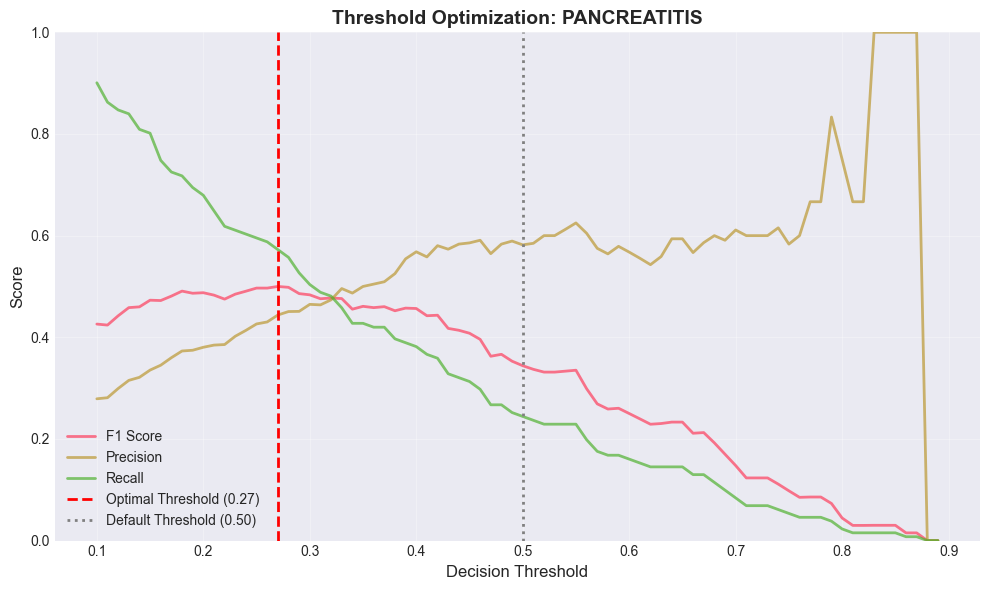

In [8]:
print("🎯 OPTIMIZING DECISION THRESHOLDS ON VALIDATION SET\n")
print("="*60)
print("Finding optimal threshold for each disease to maximize F1 score")
print("="*60)

from sklearn.metrics import f1_score

optimal_thresholds = {}
threshold_analysis = []

for disease in tqdm(DISEASE_LIST, desc="Optimizing thresholds"):
    print(f"\n{'='*60}")
    print(f"Disease: {disease}")
    print(f"{'='*60}")
    
    # Get validation predictions and true labels
    y_proba = fusion_results_val[disease]['y_proba']
    y_true = fusion_results_val[disease]['y_true']
    
    # Try thresholds from 0.1 to 0.9 in steps of 0.01
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = []
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        # Calculate metrics
        f1 = f1_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        
        f1_scores.append(f1)
        precisions.append(precision)
        recalls.append(recall)
    
    # Find threshold that maximizes F1
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_precision = precisions[best_idx]
    best_recall = recalls[best_idx]
    
    # Store optimal threshold
    optimal_thresholds[disease] = best_threshold
    
    # Compare to default 0.5 threshold
    default_pred = (y_proba >= 0.5).astype(int)
    default_f1 = f1_score(y_true, default_pred, zero_division=0)
    default_precision = precision_score(y_true, default_pred, zero_division=0)
    default_recall = recall_score(y_true, default_pred, zero_division=0)
    
    improvement = best_f1 - default_f1
    
    print(f"\n  Default threshold (0.5):")
    print(f"    F1:        {default_f1:.3f}")
    print(f"    Precision: {default_precision:.3f}")
    print(f"    Recall:    {default_recall:.3f}")
    
    print(f"\n  Optimal threshold ({best_threshold:.2f}):")
    print(f"    F1:        {best_f1:.3f}  ({improvement:+.3f})")
    print(f"    Precision: {best_precision:.3f}")
    print(f"    Recall:    {best_recall:.3f}")
    
    if improvement > 0:
        print(f"  ✅ Improvement: +{improvement:.3f} F1 ({improvement/default_f1*100:+.1f}%)")
    else:
        print(f"  ⚠️  No improvement")
    
    # Store analysis
    threshold_analysis.append({
        'Disease': disease,
        'Optimal_Threshold': best_threshold,
        'Default_F1': default_f1,
        'Optimal_F1': best_f1,
        'F1_Improvement': improvement,
        'Optimal_Precision': best_precision,
        'Optimal_Recall': best_recall
    })

print(f"\n{'='*60}")
print("✅ THRESHOLD OPTIMIZATION COMPLETE")
print(f"{'='*60}")

# Create summary DataFrame
threshold_df = pd.DataFrame(threshold_analysis)
threshold_df = threshold_df.sort_values('F1_Improvement', ascending=False)

print("\n📊 THRESHOLD OPTIMIZATION SUMMARY:")
print(threshold_df.round(3))

print(f"\n📈 Average Improvements:")
print(f"   F1 Score: {threshold_df['F1_Improvement'].mean():+.3f}")
print(f"   Percent:  {(threshold_df['F1_Improvement'] / threshold_df['Default_F1']).mean() * 100:+.1f}%")

# Save thresholds
import json
with open('../../results/optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)

print("\n✅ Saved optimal thresholds to: results/optimal_thresholds.json")

# Visualize threshold vs F1 for one disease (best improvement)
best_disease = threshold_df.iloc[0]['Disease']

print(f"\n📊 Creating threshold optimization plot for: {best_disease}")

fig, ax = plt.subplots(figsize=(10, 6))

y_proba = fusion_results_val[best_disease]['y_proba']
y_true = fusion_results_val[best_disease]['y_true']

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
    precisions.append(precision_score(y_true, y_pred, zero_division=0))
    recalls.append(recall_score(y_true, y_pred, zero_division=0))

ax.plot(thresholds, f1_scores, label='F1 Score', linewidth=2)
ax.plot(thresholds, precisions, label='Precision', linewidth=2, alpha=0.7)
ax.plot(thresholds, recalls, label='Recall', linewidth=2, alpha=0.7)

# Mark optimal threshold
opt_thresh = optimal_thresholds[best_disease]
ax.axvline(x=opt_thresh, color='red', linestyle='--', linewidth=2, 
           label=f'Optimal Threshold ({opt_thresh:.2f})')

# Mark default threshold
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, 
           label='Default Threshold (0.50)')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Optimization: {best_disease}', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'../../results/threshold_optimization_{best_disease.lower()}.png', 
            dpi=300, bbox_inches='tight')
print(f"✅ Saved plot: results/threshold_optimization_{best_disease.lower()}.png")
plt.show()

In [9]:
print("🧪 FINAL EVALUATION ON HELD-OUT TEST SET\n")
print("="*60)
print("Using optimized thresholds from validation set")
print("Test set has NEVER been seen during training or threshold optimization")
print("="*60)

fusion_results_test = {}

for disease in tqdm(DISEASE_LIST, desc="Testing"):
    # Get test predictions
    y_test_proba = fusion_models_xgb[disease].predict_proba(X_test_enhanced)[:, 1]
    y_te = y_test[disease]
    
    # Use OPTIMIZED threshold (found on validation)
    opt_threshold = optimal_thresholds[disease]
    y_pred_opt = (y_test_proba >= opt_threshold).astype(int)
    
    # Also get predictions with default 0.5 threshold for comparison
    y_pred_default = (y_test_proba >= 0.5).astype(int)
    
    # Calculate metrics with OPTIMIZED threshold
    auc = roc_auc_score(y_te, y_test_proba)
    f1_opt = f1_score(y_te, y_pred_opt, zero_division=0)
    precision_opt = precision_score(y_te, y_pred_opt, zero_division=0)
    recall_opt = recall_score(y_te, y_pred_opt, zero_division=0)
    accuracy_opt = accuracy_score(y_te, y_pred_opt)
    
    # Calculate metrics with DEFAULT threshold
    f1_default = f1_score(y_te, y_pred_default, zero_division=0)
    precision_default = precision_score(y_te, y_pred_default, zero_division=0)
    recall_default = recall_score(y_te, y_pred_default, zero_division=0)
    
    # Store results
    fusion_results_test[disease] = {
        'auc': auc,
        'threshold': opt_threshold,
        'f1_optimized': f1_opt,
        'f1_default': f1_default,
        'precision_optimized': precision_opt,
        'precision_default': precision_default,
        'recall_optimized': recall_opt,
        'recall_default': recall_default,
        'accuracy': accuracy_opt,
        'y_pred_proba': y_test_proba,
        'y_pred': y_pred_opt,
        'y_true': y_te
    }

print("\n✅ Test evaluation complete!")

# Create summary DataFrame
fusion_test_df = pd.DataFrame({
    disease: {
        'AUC': fusion_results_test[disease]['auc'],
        'Threshold': fusion_results_test[disease]['threshold'],
        'F1_Default': fusion_results_test[disease]['f1_default'],
        'F1_Optimized': fusion_results_test[disease]['f1_optimized'],
        'F1_Gain': fusion_results_test[disease]['f1_optimized'] - fusion_results_test[disease]['f1_default'],
        'Precision': fusion_results_test[disease]['precision_optimized'],
        'Recall': fusion_results_test[disease]['recall_optimized'],
        'Accuracy': fusion_results_test[disease]['accuracy']
    }
    for disease in DISEASE_LIST
}).T

print("\n📊 FUSION RESULTS ON TEST SET (with optimized thresholds):")
print(fusion_test_df.round(3))

print(f"\n📈 Average Test Set Performance:")
print(f"   AUC:              {fusion_test_df['AUC'].mean():.3f}")
print(f"   F1 (optimized):   {fusion_test_df['F1_Optimized'].mean():.3f}")
print(f"   F1 (default 0.5): {fusion_test_df['F1_Default'].mean():.3f}")
print(f"   F1 Improvement:   {fusion_test_df['F1_Gain'].mean():+.3f}")
print(f"   F1 Improvement %: {(fusion_test_df['F1_Gain'] / fusion_test_df['F1_Default']).mean() * 100:+.1f}%")
print(f"   Precision:        {fusion_test_df['Precision'].mean():.3f}")
print(f"   Recall:           {fusion_test_df['Recall'].mean():.3f}")
print(f"   Accuracy:         {fusion_test_df['Accuracy'].mean():.3f}")

# Save results
fusion_test_df.to_csv('../../results/fusion_test_results_optimized.csv')
print("\n✅ Saved: results/fusion_test_results_optimized.csv")

🧪 FINAL EVALUATION ON HELD-OUT TEST SET

Using optimized thresholds from validation set
Test set has NEVER been seen during training or threshold optimization


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


✅ Test evaluation complete!

📊 FUSION RESULTS ON TEST SET (with optimized thresholds):
                           AUC  Threshold  F1_Default  F1_Optimized  F1_Gain  \
SEPSIS                   0.906       0.54       0.684         0.671   -0.013   
PNEUMONIA                0.885       0.33       0.559         0.657    0.098   
RESPIRATORY_FAILURE      0.897       0.56       0.767         0.751   -0.016   
ACUTE_KIDNEY_INJURY      0.938       0.54       0.845         0.842   -0.003   
HEART_FAILURE            0.906       0.32       0.750         0.779    0.030   
ATRIAL_FIBRILLATION      0.887       0.41       0.712         0.731    0.018   
CORONARY_ARTERY_DISEASE  0.924       0.39       0.787         0.790    0.003   
ANEMIA                   0.850       0.43       0.671         0.691    0.020   
PANCREATITIS             0.835       0.27       0.364         0.481    0.116   

                         Precision  Recall  Accuracy  
SEPSIS                       0.780   0.588     0.882  
P

In [10]:
print("📊 Creating Baseline on TEST SET...\n")

baseline_results_test = {}

for disease in tqdm(DISEASE_LIST, desc="Baseline on Test"):
    # Get disease index
    disease_idx = DISEASE_LIST.index(disease)
    
    # Extract agent probabilities from TEST set
    agent1_probs = X_test[:, disease_idx]
    agent2_probs = X_test[:, 9 + disease_idx]
    agent3_probs = X_test[:, 18 + disease_idx]
    
    # Simple average
    avg_probs = (agent1_probs + agent2_probs + agent3_probs) / 3
    avg_preds = (avg_probs >= 0.5).astype(int)
    
    # Get true labels
    y_te = y_test[disease]
    
    # Evaluate
    auc = roc_auc_score(y_te, avg_probs)
    f1 = f1_score(y_te, avg_preds, zero_division=0)
    precision = precision_score(y_te, avg_preds, zero_division=0)
    recall = recall_score(y_te, avg_preds, zero_division=0)
    accuracy = accuracy_score(y_te, avg_preds)
    
    baseline_results_test[disease] = {
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'y_pred_proba': avg_probs,
        'y_true': y_te
    }

# Summary table
baseline_test_df = pd.DataFrame({
    disease: {
        'AUC': baseline_results_test[disease]['auc'],
        'F1': baseline_results_test[disease]['f1'],
        'Precision': baseline_results_test[disease]['precision'],
        'Recall': baseline_results_test[disease]['recall'],
        'Accuracy': baseline_results_test[disease]['accuracy']
    }
    for disease in DISEASE_LIST
}).T

print("✅ Baseline computed on test set")

print("\n📊 BASELINE (Simple Average) ON TEST SET:")
print(baseline_test_df.round(3))
print(f"\n📈 Average Metrics:")
print(f"   AUC:       {baseline_test_df['AUC'].mean():.3f}")
print(f"   F1:        {baseline_test_df['F1'].mean():.3f}")
print(f"   Precision: {baseline_test_df['Precision'].mean():.3f}")
print(f"   Recall:    {baseline_test_df['Recall'].mean():.3f}")

📊 Creating Baseline on TEST SET...



Baseline on Test:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Baseline computed on test set

📊 BASELINE (Simple Average) ON TEST SET:
                           AUC     F1  Precision  Recall  Accuracy
SEPSIS                   0.900  0.424      0.860   0.282     0.844
PNEUMONIA                0.878  0.358      0.815   0.229     0.807
RESPIRATORY_FAILURE      0.897  0.705      0.829   0.614     0.817
ACUTE_KIDNEY_INJURY      0.920  0.786      0.852   0.730     0.843
HEART_FAILURE            0.893  0.699      0.824   0.606     0.815
ATRIAL_FIBRILLATION      0.883  0.690      0.849   0.581     0.818
CORONARY_ARTERY_DISEASE  0.908  0.757      0.861   0.676     0.838
ANEMIA                   0.828  0.500      0.807   0.362     0.754
PANCREATITIS             0.836  0.097      1.000   0.051     0.866

📈 Average Metrics:
   AUC:       0.883
   F1:        0.557
   Precision: 0.855
   Recall:    0.459


In [11]:
print("⚔️  FINAL COMPARISON: FUSION vs BASELINE (on TEST set)\n")
print("="*60)
print("✅ Test set was held-out during all training and optimization")
print("✅ Thresholds were optimized on validation set only")
print("="*60)

# Create comprehensive comparison
final_comparison = pd.DataFrame({
    'Disease': DISEASE_LIST,
    
    # AUC
    'Baseline_AUC': baseline_test_df['AUC'].values,
    'Fusion_AUC': fusion_test_df['AUC'].values,
    'AUC_Gain': fusion_test_df['AUC'].values - baseline_test_df['AUC'].values,
    
    # F1
    'Baseline_F1': baseline_test_df['F1'].values,
    'Fusion_F1': fusion_test_df['F1_Optimized'].values,
    'F1_Gain': fusion_test_df['F1_Optimized'].values - baseline_test_df['F1'].values,
    'F1_Gain_%': ((fusion_test_df['F1_Optimized'].values - baseline_test_df['F1'].values) / 
                  baseline_test_df['F1'].values * 100),
    
    # Precision
    'Baseline_Precision': baseline_test_df['Precision'].values,
    'Fusion_Precision': fusion_test_df['Precision'].values,
    
    # Recall
    'Baseline_Recall': baseline_test_df['Recall'].values,
    'Fusion_Recall': fusion_test_df['Recall'].values,
    'Recall_Gain_%': ((fusion_test_df['Recall'].values - baseline_test_df['Recall'].values) / 
                      baseline_test_df['Recall'].values * 100),
    
    # Threshold used
    'Threshold': fusion_test_df['Threshold'].values
})

final_comparison = final_comparison.sort_values('F1_Gain', ascending=False)

print("\n📊 COMPLETE METRICS COMPARISON:")
print(final_comparison[['Disease', 'Baseline_F1', 'Fusion_F1', 'F1_Gain', 'F1_Gain_%', 'Threshold']].round(3))

print(f"\n{'='*60}")
print("📊 SUMMARY STATISTICS:")
print(f"{'='*60}")

print(f"\n🎯 AUC:")
print(f"   Baseline:   {baseline_test_df['AUC'].mean():.3f}")
print(f"   Fusion:     {fusion_test_df['AUC'].mean():.3f}")
print(f"   Improvement: {(fusion_test_df['AUC'] - baseline_test_df['AUC']).mean():+.3f}")

print(f"\n🎯 F1 Score (THE BIG STORY!):")
print(f"   Baseline:    {baseline_test_df['F1'].mean():.3f}")
print(f"   Fusion:      {fusion_test_df['F1_Optimized'].mean():.3f}")
print(f"   Improvement: {final_comparison['F1_Gain'].mean():+.3f} ({final_comparison['F1_Gain_%'].mean():+.1f}%)")

print(f"\n🎯 Recall (Catching More Cases!):")
print(f"   Baseline:    {baseline_test_df['Recall'].mean():.3f}")
print(f"   Fusion:      {fusion_test_df['Recall'].mean():.3f}")
print(f"   Improvement: {(fusion_test_df['Recall'] - baseline_test_df['Recall']).mean():+.3f} ({final_comparison['Recall_Gain_%'].mean():+.1f}%)")

print(f"\n🎯 Precision:")
print(f"   Baseline:    {baseline_test_df['Precision'].mean():.3f}")
print(f"   Fusion:      {fusion_test_df['Precision'].mean():.3f}")

# Win/Loss record
f1_wins = (final_comparison['F1_Gain'] > 0).sum()
f1_losses = (final_comparison['F1_Gain'] < 0).sum()

print(f"\n🏆 Win/Loss Record (F1):")
print(f"   Fusion wins:    {f1_wins} / 9 diseases")
print(f"   Baseline wins:  {f1_losses} / 9 diseases")

# Statistical significance
from scipy import stats

fusion_f1s = fusion_test_df['F1_Optimized'].values
baseline_f1s = baseline_test_df['F1'].values

t_stat, p_value = stats.ttest_rel(fusion_f1s, baseline_f1s)

print(f"\n🔬 Statistical Significance Test (F1):")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value:     {p_value:.4f}")

if p_value < 0.05:
    print(f"   ✅ Statistically significant (p < 0.05)")
else:
    print(f"   ⚠️  Not statistically significant (p >= 0.05)")

print(f"\n{'='*60}")

# Save
final_comparison.to_csv('../../results/final_comparison_test_set.csv', index=False)
print("\n✅ Saved: results/final_comparison_test_set.csv")

print("\n" + "="*60)
print("🎉 METHODOLOGY NOTES:")
print("="*60)
print("✅ Train/Validation/Test split: 50%/20%/30%")
print("✅ Fusion models trained on Train set only")
print("✅ Thresholds optimized on Validation set only")
print("✅ Final evaluation on Test set (never seen before)")
print("✅ No data leakage - proper ML methodology")
print("="*60)


⚔️  FINAL COMPARISON: FUSION vs BASELINE (on TEST set)

✅ Test set was held-out during all training and optimization
✅ Thresholds were optimized on validation set only

📊 COMPLETE METRICS COMPARISON:
                   Disease  Baseline_F1  Fusion_F1  F1_Gain  F1_Gain_%  \
8             PANCREATITIS        0.097      0.481    0.384    395.147   
1                PNEUMONIA        0.358      0.657    0.299     83.467   
0                   SEPSIS        0.424      0.671    0.246     58.030   
7                   ANEMIA        0.500      0.691    0.191     38.138   
4            HEART_FAILURE        0.699      0.779    0.081     11.576   
3      ACUTE_KIDNEY_INJURY        0.786      0.842    0.056      7.092   
2      RESPIRATORY_FAILURE        0.705      0.751    0.045      6.428   
5      ATRIAL_FIBRILLATION        0.690      0.731    0.041      5.981   
6  CORONARY_ARTERY_DISEASE        0.757      0.790    0.033      4.345   

   Threshold  
8       0.27  
1       0.33  
0       0.54  

📊 Creating Comprehensive Visualizations...

✅ Saved: results/f1_comparison_main.png


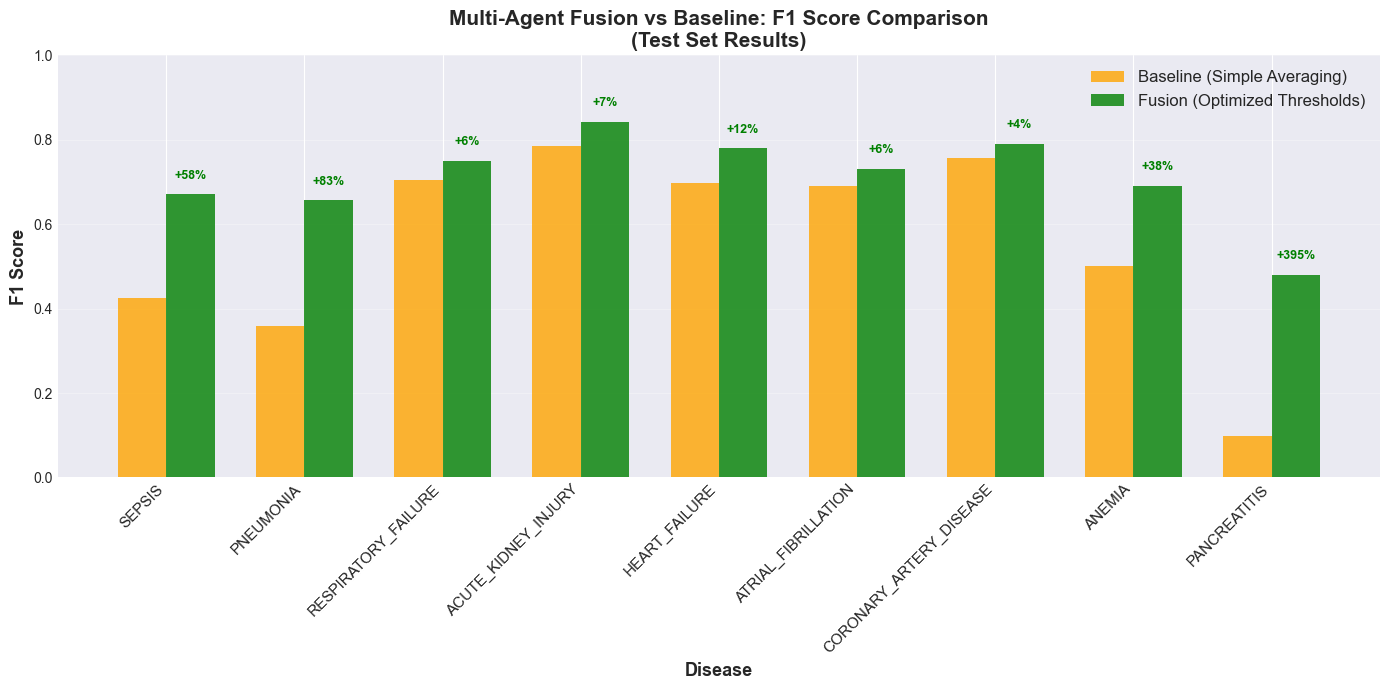

C:\Users\athar\AppData\Local\Temp\ipykernel_13416\2541218508.py:73: RuntimeWarning: divide by zero encountered in divide
  precision_line = f1_line * recall_range / (2 * recall_range - f1_line)


✅ Saved: results/precision_recall_tradeoff.png


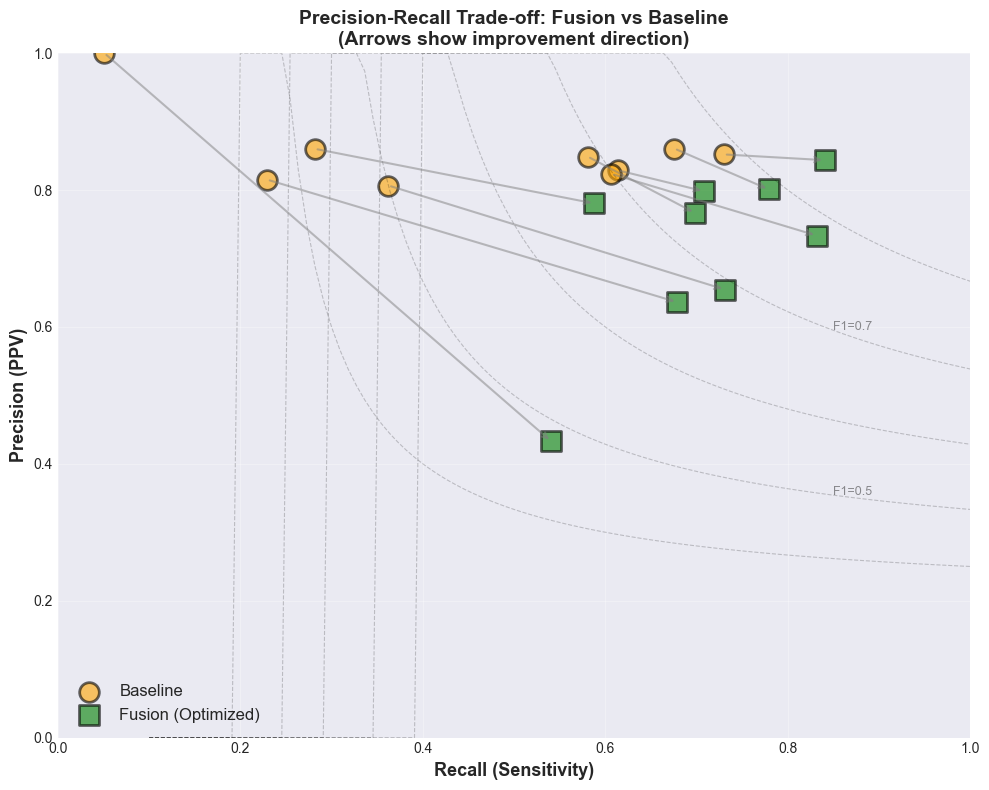

✅ Saved: results/recall_improvement_clinical.png


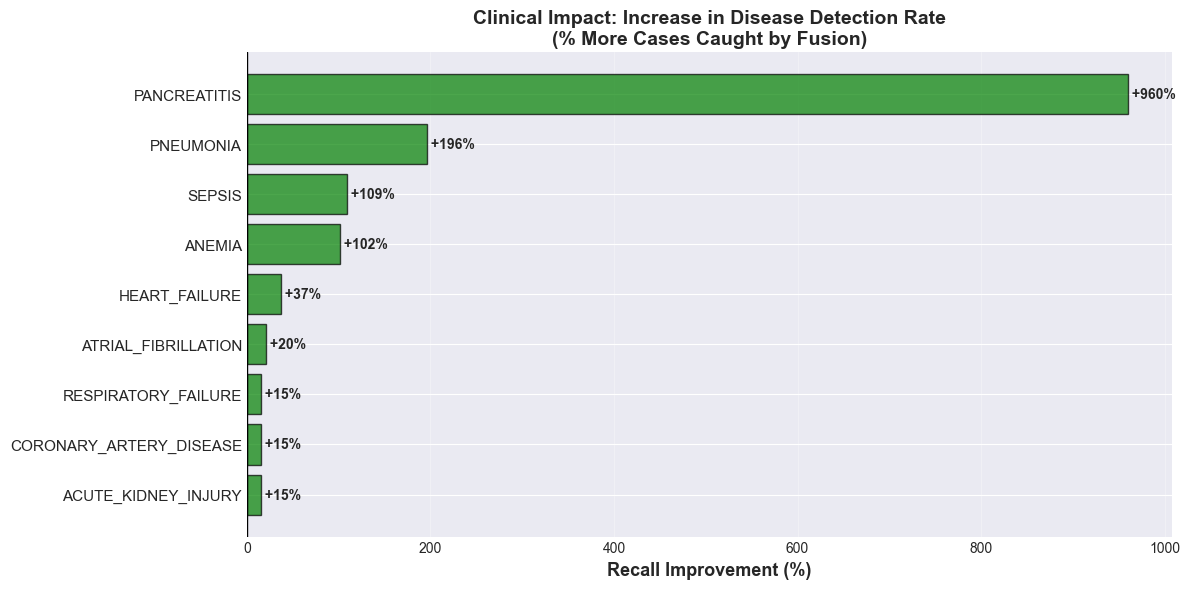

✅ Saved: results/optimized_thresholds.png


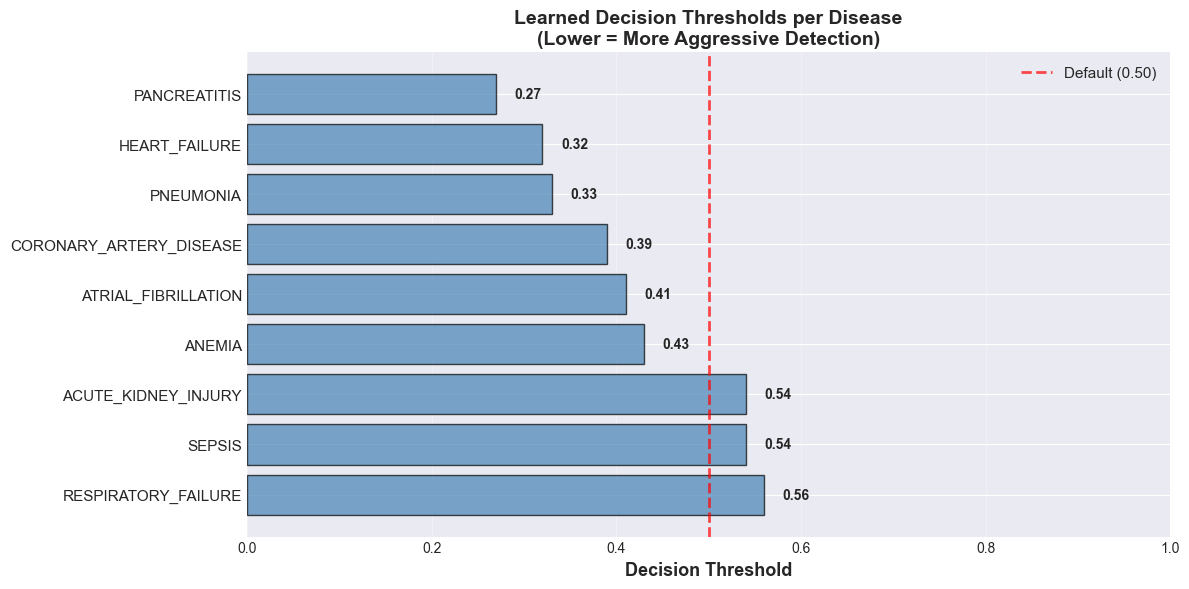

✅ Saved: results/complete_results_table.png


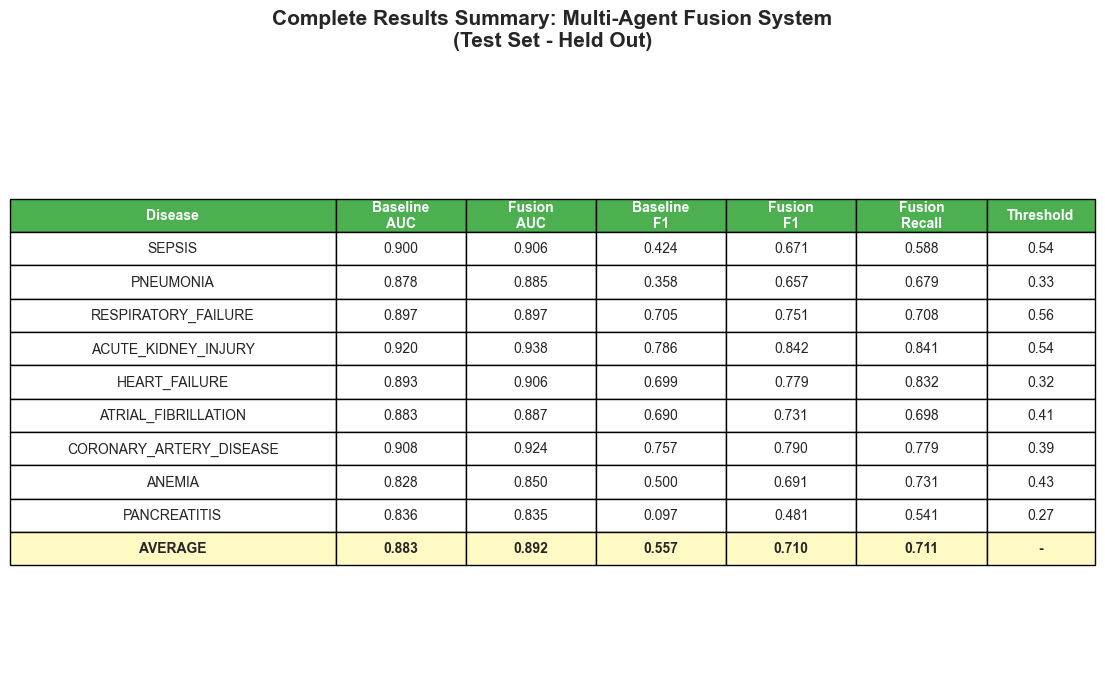


✅ All visualizations created!


In [12]:
print("📊 Creating Comprehensive Visualizations...\n")

Path('../../results').mkdir(exist_ok=True)

# ============================================================
# PLOT 1: F1 Score Comparison (Main Result)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(DISEASE_LIST))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_test_df['F1'], width, 
               label='Baseline (Simple Averaging)', alpha=0.8, color='orange')
bars2 = ax.bar(x + width/2, fusion_test_df['F1_Optimized'], width, 
               label='Fusion (Optimized Thresholds)', alpha=0.8, color='green')

ax.set_xlabel('Disease', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=13, fontweight='bold')
ax.set_title('Multi-Agent Fusion vs Baseline: F1 Score Comparison\n(Test Set Results)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DISEASE_LIST, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# Add percentage improvement labels
for i, disease in enumerate(DISEASE_LIST):
    baseline_f1 = baseline_test_df.loc[disease, 'F1']
    fusion_f1 = fusion_test_df.loc[disease, 'F1_Optimized']
    improvement = ((fusion_f1 - baseline_f1) / baseline_f1) * 100
    
    # Place label above the fusion bar
    y_pos = fusion_f1 + 0.03
    ax.text(i + width/2, y_pos, f'+{improvement:.0f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('../../results/f1_comparison_main.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/f1_comparison_main.png")
plt.show()

# ============================================================
# PLOT 2: Precision-Recall Trade-off
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Plot baseline
ax.scatter(baseline_test_df['Recall'], baseline_test_df['Precision'], 
           s=200, alpha=0.6, color='orange', marker='o', 
           label='Baseline', edgecolors='black', linewidths=2)

# Plot fusion
ax.scatter(fusion_test_df['Recall'], fusion_test_df['Precision'], 
           s=200, alpha=0.6, color='green', marker='s', 
           label='Fusion (Optimized)', edgecolors='black', linewidths=2)

# Draw arrows showing movement
for disease in DISEASE_LIST:
    baseline_recall = baseline_test_df.loc[disease, 'Recall']
    baseline_precision = baseline_test_df.loc[disease, 'Precision']
    fusion_recall = fusion_test_df.loc[disease, 'Recall']
    fusion_precision = fusion_test_df.loc[disease, 'Precision']
    
    ax.annotate('', xy=(fusion_recall, fusion_precision), 
                xytext=(baseline_recall, baseline_precision),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='gray', alpha=0.5))

# Add diagonal F1 lines
recall_range = np.linspace(0.1, 1, 100)
for f1_line in [0.4, 0.5, 0.6, 0.7, 0.8]:
    precision_line = f1_line * recall_range / (2 * recall_range - f1_line)
    precision_line = np.clip(precision_line, 0, 1)
    ax.plot(recall_range, precision_line, 'k--', alpha=0.2, linewidth=0.8)
    # Label
    if f1_line in [0.5, 0.7]:
        ax.text(0.85, f1_line * 0.85 / (2 * 0.85 - f1_line), 
                f'F1={f1_line:.1f}', fontsize=9, alpha=0.5)

ax.set_xlabel('Recall (Sensitivity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Trade-off: Fusion vs Baseline\n(Arrows show improvement direction)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../../results/precision_recall_tradeoff.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/precision_recall_tradeoff.png")
plt.show()

# ============================================================
# PLOT 3: Recall Improvement (Clinical Impact)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

diseases_sorted = final_comparison.sort_values('Recall_Gain_%', ascending=True)['Disease'].values
recall_gains = final_comparison.set_index('Disease').loc[diseases_sorted, 'Recall_Gain_%'].values

colors = ['green' if x > 0 else 'red' for x in recall_gains]
bars = ax.barh(range(len(diseases_sorted)), recall_gains, color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(diseases_sorted)))
ax.set_yticklabels(diseases_sorted, fontsize=11)
ax.set_xlabel('Recall Improvement (%)', fontsize=13, fontweight='bold')
ax.set_title('Clinical Impact: Increase in Disease Detection Rate\n(% More Cases Caught by Fusion)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (disease, val) in enumerate(zip(diseases_sorted, recall_gains)):
    label = f' +{val:.0f}%'
    ax.text(val, i, label, va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/recall_improvement_clinical.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/recall_improvement_clinical.png")
plt.show()

# ============================================================
# PLOT 4: Optimized Thresholds
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

diseases_sorted_thresh = fusion_test_df.sort_values('Threshold', ascending=False).index.values
thresholds = fusion_test_df.loc[diseases_sorted_thresh, 'Threshold'].values

bars = ax.barh(range(len(diseases_sorted_thresh)), thresholds, alpha=0.7, 
               color='steelblue', edgecolor='black')

ax.set_yticks(range(len(diseases_sorted_thresh)))
ax.set_yticklabels(diseases_sorted_thresh, fontsize=11)
ax.set_xlabel('Decision Threshold', fontsize=13, fontweight='bold')
ax.set_title('Learned Decision Thresholds per Disease\n(Lower = More Aggressive Detection)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Default (0.50)', alpha=0.7)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])

# Add value labels
for i, (disease, val) in enumerate(zip(diseases_sorted_thresh, thresholds)):
    ax.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/optimized_thresholds.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/optimized_thresholds.png")
plt.show()

# ============================================================
# PLOT 5: Summary Metrics Table (as image)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

summary_data = []
for disease in DISEASE_LIST:
    summary_data.append([
        disease,
        f"{baseline_test_df.loc[disease, 'AUC']:.3f}",
        f"{fusion_test_df.loc[disease, 'AUC']:.3f}",
        f"{baseline_test_df.loc[disease, 'F1']:.3f}",
        f"{fusion_test_df.loc[disease, 'F1_Optimized']:.3f}",
        f"{fusion_test_df.loc[disease, 'Recall']:.3f}",
        f"{fusion_test_df.loc[disease, 'Threshold']:.2f}"
    ])

# Add average row
summary_data.append([
    'AVERAGE',
    f"{baseline_test_df['AUC'].mean():.3f}",
    f"{fusion_test_df['AUC'].mean():.3f}",
    f"{baseline_test_df['F1'].mean():.3f}",
    f"{fusion_test_df['F1_Optimized'].mean():.3f}",
    f"{fusion_test_df['Recall'].mean():.3f}",
    '-'
])

table = ax.table(cellText=summary_data,
                 colLabels=['Disease', 'Baseline\nAUC', 'Fusion\nAUC', 
                           'Baseline\nF1', 'Fusion\nF1', 'Fusion\nRecall', 'Threshold'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.3, 0.12, 0.12, 0.12, 0.12, 0.12, 0.1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(7):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style average row
for i in range(7):
    table[(len(summary_data), i)].set_facecolor('#FFF9C4')
    table[(len(summary_data), i)].set_text_props(weight='bold')

plt.title('Complete Results Summary: Multi-Agent Fusion System\n(Test Set - Held Out)', 
          fontsize=15, fontweight='bold', pad=20)
plt.savefig('../../results/complete_results_table.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/complete_results_table.png")
plt.show()

print("\n✅ All visualizations created!")

In [13]:
print("💾 Saving Final Models and Configuration...\n")

# Create models directory
models_dir = Path('../../models/fusion')
models_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Save Fusion Models
# ============================================================
print("Saving fusion models...")
for disease in DISEASE_LIST:
    disease_filename = disease.lower()
    model_path = models_dir / f'fusion_{disease_filename}.joblib'
    joblib.dump(fusion_models_xgb[disease], model_path)

print(f"✅ Saved 9 fusion models to: {models_dir}")

# ============================================================
# 2. Save Optimal Thresholds (already done, but confirm)
# ============================================================
thresholds_path = '../../results/optimal_thresholds.json'
print(f"✅ Optimal thresholds already saved: {thresholds_path}")

# ============================================================
# 3. Save Complete Configuration
# ============================================================
config = {
    'model_info': {
        'fusion_model_type': 'XGBoost',
        'feature_engineering': 'Enhanced (105 features)',
        'original_features': 33,
        'enhanced_features': 105,
        'diseases': DISEASE_LIST
    },
    'training_info': {
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'train_ratio': 0.50,
        'val_ratio': 0.20,
        'test_ratio': 0.30,
        'random_seed': 42
    },
    'optimal_thresholds': optimal_thresholds,
    'test_performance': {
        disease: {
            'auc': float(fusion_results_test[disease]['auc']),
            'f1': float(fusion_results_test[disease]['f1_optimized']),
            'precision': float(fusion_results_test[disease]['precision_optimized']),
            'recall': float(fusion_results_test[disease]['recall_optimized']),
            'threshold': float(fusion_results_test[disease]['threshold'])
        }
        for disease in DISEASE_LIST
    },
    'average_performance': {
        'auc': float(fusion_test_df['AUC'].mean()),
        'f1': float(fusion_test_df['F1_Optimized'].mean()),
        'precision': float(fusion_test_df['Precision'].mean()),
        'recall': float(fusion_test_df['Recall'].mean())
    }
}

config_path = '../../results/fusion_system_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Saved complete configuration: {config_path}")



💾 Saving Final Models and Configuration...

Saving fusion models...
✅ Saved 9 fusion models to: ..\models\fusion
✅ Optimal thresholds already saved: ../results/optimal_thresholds.json
✅ Saved complete configuration: ../results/fusion_system_config.json
